# Higher Education Rate Analysis
## Finding the "Best" Neighborhood in Pittsburgh

Kevin Harned

Sub-Metric: Higher education rate (% of population enrolled in college or graduate school)

Dataset: Pittsburgh american community survey 2015 - school enrollment by race/ethnicity

Source: [WPRDC](https://data.wprdc.org/)

### Introduction

For this analysis and project, I'm defining "best" neighborhood as one with a high rate of residents pursuing higher education (college undergraduate or graduate/professional school). This metric can indicate a few things, such as access to educational opportunities, a community that values education, proximity to universities and colleges, and potential for an educated workforce.

I'll analyze school enrollment data across all racial and ethnic groups to calculate an overall higher education rate for each Pittsburgh neighborhood. Before I decided to do rate of residents pursuing higher education, I thought of a few weeks to measure educational bestness. Something I decided against was overall school enrollment rate. I decided against this because it would not distinguish between elementary school and college, so it would not capture the highly educated adults. I was also thinking about doing graduate school rate only. But I also decided against this because it would only highlight neighborhoods next to places like Pitt and CMU.

---
## First step: Import Libraries

In [1]:
# working with pandas
import pandas as pd

# creating charts and graphs
import matplotlib.pyplot as plt

# math operations
import numpy as np

# making the charts look nice
plt.style.use('seaborn-v0_8-whitegrid')

# setting the default size for all the charts
plt.rcParams['figure.figsize'] = (12, 8)

---
## Second step: Load the Data

We have 8 CSV files, one for each racial/ethnic category. We'll load them all and combine them to get total population counts.

In [2]:
# List of all the csv files
files = [
    'school-enrollment-by-detailed-level-of-school-for-the-population-3-years-and-over-white-alone.csv',
    'school-enrollment-by-detailed-level-of-school-for-the-population-3-years-and-over-black-or-afric.csv',
    'school-enrollment-by-detailed-level-of-school-for-the-population-3-years-and-over-asian-alone.csv',
    'school-enrollment-by-detailed-level-of-school-for-the-population-3-years-and-over-hispanic-or-la.csv',
    'school-enrollment-by-detailed-level-of-school-for-the-population-3-years-and-over-american-india.csv',
    'school-enrollment-by-detailed-level-of-school-for-the-population-3-years-and-over-native-hawaiia.csv',
    'school-enrollment-by-detailed-level-of-school-for-the-population-3-years-and-over-some-other-rac.csv',
    'school-enrollment-by-detailed-level-of-school-for-the-population-3-years-and-over-two-or-more-ra.csv'
]

# reading part of the csv file and turning it into a table
df_sample = pd.read_csv(files[0])

# how many rows and columns in the table it shows
print(f"Shape: {df_sample.shape}")

# converting it into a regular python list
print(f"\nColumns: {df_sample.columns.tolist()}")

Shape: (91, 40)

Columns: ['Neighborhood', 'Id', 'Estimate; Total:', 'Margin of Error; Total:', 'Estimate; Enrolled in school:', 'Margin of Error; Enrolled in school:', 'Estimate; Enrolled in school: - Enrolled in nursery school, preschool', 'Margin of Error; Enrolled in school: - Enrolled in nursery school, preschool', 'Estimate; Enrolled in school: - Enrolled in kindergarten', 'Margin of Error; Enrolled in school: - Enrolled in kindergarten', 'Estimate; Enrolled in school: - Enrolled in grade 1', 'Margin of Error; Enrolled in school: - Enrolled in grade 1', 'Estimate; Enrolled in school: - Enrolled in grade 2', 'Margin of Error; Enrolled in school: - Enrolled in grade 2', 'Estimate; Enrolled in school: - Enrolled in grade 3', 'Margin of Error; Enrolled in school: - Enrolled in grade 3', 'Estimate; Enrolled in school: - Enrolled in grade 4', 'Margin of Error; Enrolled in school: - Enrolled in grade 4', 'Estimate; Enrolled in school: - Enrolled in grade 5', 'Margin of Error; Enrolled i

In [3]:
# shows what actual data will look like
df_sample.head()

,Neighborhood,Id,Estimate; Total:,Margin of Error; Total:,Estimate; Enrolled in school:,Margin of Error; Enrolled in school:,"Estimate; Enrolled in school: - Enrolled in nursery school, preschool","Margin of Error; Enrolled in school: - Enrolled in nursery school, preschool",Estimate; Enrolled in school: - Enrolled in kindergarten,Margin of Error; Enrolled in school: - Enrolled in kindergarten,...,Estimate; Enrolled in school: - Enrolled in grade 11,Margin of Error; Enrolled in school: - Enrolled in grade 11,Estimate; Enrolled in school: - Enrolled in grade 12,Margin of Error; Enrolled in school: - Enrolled in grade 12,"Estimate; Enrolled in school: - Enrolled in college, undergraduate years","Margin of Error; Enrolled in school: - Enrolled in college, undergraduate years",Estimate; Enrolled in school: - Graduate or professional school,Margin of Error; Enrolled in school: - Graduate or professional school,Estimate; Not enrolled in school,Margin of Error; Not enrolled in school
0,Allegheny Center,1,832.0,135.000000,159.0,66.000000,14.0,20.000000,0.0,10.000000,...,0.0,10.000000,0.0,10.000000,103.0,58.000000,22.0,16.000000,673.0,114.000000
1,Allegheny West,2,294.0,70.000000,25.0,22.000000,0.0,10.000000,0.0,10.000000,...,0.0,10.000000,0.0,10.000000,0.0,10.000000,25.0,22.000000,269.0,70.000000
2,Allentown,3,1293.0,299.869972,247.0,156.831119,0.0,17.320508,0.0,17.320508,...,0.0,17.320508,11.0,17.549929,39.0,50.645829,0.0,17.320508,1046.0,196.211620
3,Arlington,4,1421.0,241.165918,337.0,108.724422,7.0,17.916473,6.0,17.916473,...,29.0,27.000000,17.0,27.856777,114.0,61.733297,16.0,18.493242,1084.0,176.703141
4,Arlington Heights,5,64.0,79.000000,0.0,10.000000,0.0,10.000000,0.0,10.000000,...,0.0,10.000000,0.0,10.000000,0.0,10.000000,0.0,10.000000,64.0,79.000000


---
## Third step: Combine All Racial/Ethnic Groups

To get the total higher education rate, we need to sum up the populations across all racial groups for each neighborhood.

In [4]:
# creating an empty list for now
all_dfs = []

# using a for loop for each item in the list
for file in files:
    
    # read the current CSV file into a dataframe
    df = pd.read_csv(file)
    
    # adds the dataframe to the list
    all_dfs.append(df)

# counts how many items are in a list
print(f"Loaded {len(all_dfs)} files")

Loaded 8 files


In [5]:
# gets the column names as a list
cols = df_sample.columns.tolist()

print("Looking for relevant columns")

# go through each column name
for col in cols:
    
    # converting everything to lowercase and then looking for strings
    if 'college' in col.lower() or 'graduate' in col.lower() or 'total' in col.lower():
        
        # indent and print the column name
        print(f"  - {col}")

Looking for relevant columns
  - Estimate; Total:
  - Margin of Error; Total:
  - Estimate; Enrolled in school: - Enrolled in college, undergraduate years
  - Margin of Error; Enrolled in school: - Enrolled in college, undergraduate years
  - Estimate; Enrolled in school: - Graduate or professional school
  - Margin of Error; Enrolled in school: - Graduate or professional school


In [6]:
# creating an empty table to store results
combined = pd.DataFrame()

# copying the neighborhood column
combined['Neighborhood'] = all_dfs[0]['Neighborhood']

# creating new columns and setting the values equal to 0
combined['Total_Population'] = 0
combined['College_Undergraduate'] = 0
combined['Graduate_Professional'] = 0

# looping through the dataframe for each racial group
for df in all_dfs:
    
    # saving the exaxct column names from the csv file as variables
    total_col = 'Estimate; Total:'
    college_col = 'Estimate; Enrolled in school: - Enrolled in college, undergraduate years'
    grad_col = 'Estimate; Enrolled in school: - Graduate or professional school'
    
    # converting text to numbers and catching any errors
    
    # adding total population to the running total
    combined['Total_Population'] += pd.to_numeric(df[total_col], errors='coerce').fillna(0)
    
    # adding college enrollment to the running total
    combined['College_Undergraduate'] += pd.to_numeric(df[college_col], errors='coerce').fillna(0)
    
    # adding graduate school to the running total
    combined['Graduate_Professional'] += pd.to_numeric(df[grad_col], errors='coerce').fillna(0)

# show the first 10 rows
combined.head(10)

,Neighborhood,Total_Population,College_Undergraduate,Graduate_Professional
0,Allegheny Center,1423.0,173.0,51.0
1,Allegheny West,367.0,2.0,29.0
2,Allentown,2520.0,125.0,74.0
3,Arlington,1862.0,142.0,20.0
4,Arlington Heights,221.0,20.0,0.0
5,Banksville,3851.0,23.0,99.0
6,Bedford Dwellings,1286.0,24.0,0.0
7,Beechview,8089.0,569.0,210.0
8,Beltzhoover,1609.0,140.0,6.0
9,Bloomfield,8673.0,732.0,996.0


---
## Fourth step: Calculate Higher Education Rate

In [7]:
# create a new column for the information added together
combined['Higher_Ed_Total'] = combined['College_Undergraduate'] + combined['Graduate_Professional']

# find what percent is higher education
combined['Higher_Ed_Rate'] = (combined['Higher_Ed_Total'] / combined['Total_Population']) * 100

# replace the neighborhoods with a population of 0 and fix the errors
combined['Higher_Ed_Rate'] = combined['Higher_Ed_Rate'].replace([np.inf, -np.inf], np.nan)

# show the first 10 rows
combined.head(10)

,Neighborhood,Total_Population,College_Undergraduate,Graduate_Professional,Higher_Ed_Total,Higher_Ed_Rate
0,Allegheny Center,1423.0,173.0,51.0,224.0,15.741391
1,Allegheny West,367.0,2.0,29.0,31.0,8.446866
2,Allentown,2520.0,125.0,74.0,199.0,7.896825
3,Arlington,1862.0,142.0,20.0,162.0,8.700322
4,Arlington Heights,221.0,20.0,0.0,20.0,9.049774
5,Banksville,3851.0,23.0,99.0,122.0,3.168008
6,Bedford Dwellings,1286.0,24.0,0.0,24.0,1.866252
7,Beechview,8089.0,569.0,210.0,779.0,9.630362
8,Beltzhoover,1609.0,140.0,6.0,146.0,9.073959
9,Bloomfield,8673.0,732.0,996.0,1728.0,19.923902


In [8]:
# show the basic statistics
print("Higher Education Rate Statistics:")

# caclculate the average
print(f"  Mean: {combined['Higher_Ed_Rate'].mean():.2f}%")

# calculate the median
print(f"  Median: {combined['Higher_Ed_Rate'].median():.2f}%")

# find the smallest value
print(f"  Min: {combined['Higher_Ed_Rate'].min():.2f}%")

# find the greatest value
print(f"  Max: {combined['Higher_Ed_Rate'].max():.2f}%")

# calculate the standard deviation
print(f"  Std Dev: {combined['Higher_Ed_Rate'].std():.2f}%")

Higher Education Rate Statistics:
  Mean: 12.52%
  Median: 7.46%
  Min: 0.00%
  Max: 78.57%
  Std Dev: 14.97%


---
## Next step: Rank the Neighborhoods

In [9]:
# sort the designated column in descending order
ranked = combined.sort_values('Higher_Ed_Rate', ascending=False).reset_index(drop=True)

# creating a new ranking column
ranked['Rank'] = range(1, len(ranked) + 1)

# making a header
print("top 10 neighborhoods by higher education rate:\n")

# show the first 10 rows only
top_10 = ranked[['Rank', 'Neighborhood', 'Higher_Ed_Rate', 'Higher_Ed_Total', 'Total_Population']].head(10)

# display it
top_10

top 10 neighborhoods by higher education rate:



,Rank,Neighborhood,Higher_Ed_Rate,Higher_Ed_Total,Total_Population
0,1,Central Oakland,78.573809,4716.0,6002.0
1,2,North Oakland,72.412050,7163.0,9892.0
2,3,Bluff,56.585441,3669.0,6484.0
3,4,Terrace Village,50.215332,1166.0,2322.0
4,5,South Oakland,47.627119,1405.0,2950.0
5,6,Squirrel Hill North,42.548765,4908.0,11535.0
6,7,Central Business District,40.356369,1676.0,4153.0
7,8,West Oakland,39.317245,668.0,1699.0
8,9,South Shore,33.333333,4.0,12.0
9,10,Shadyside,32.041325,4373.0,13648.0


In [10]:
# bottom 10 worst neighborhoods here
print("bottom 10 neighborhoods by education rate:\n")

# show the last 10 rows, not the first 10 rows
bottom_10 = ranked[['Rank', 'Neighborhood', 'Higher_Ed_Rate', 'Higher_Ed_Total', 'Total_Population']].tail(10)

# display the table
bottom_10

bottom 10 neighborhoods by education rate:



,Rank,Neighborhood,Higher_Ed_Rate,Higher_Ed_Total,Total_Population
81,82,Homewood West,2.663438,22.0,826.0
82,83,Bon Air,2.173913,19.0,874.0
83,84,Larimer,1.873829,30.0,1601.0
84,85,Bedford Dwellings,1.866252,24.0,1286.0
85,86,Mt. Oliver,1.833333,11.0,600.0
86,87,Hays,1.595745,6.0,376.0
87,88,Spring Garden,0.697674,6.0,860.0
88,89,Chateau,0.000000,0.0,3.0
89,90,North Shore,0.000000,0.0,212.0
90,91,St. Clair,0.000000,0.0,261.0


---
## Step six: Visualize the Results

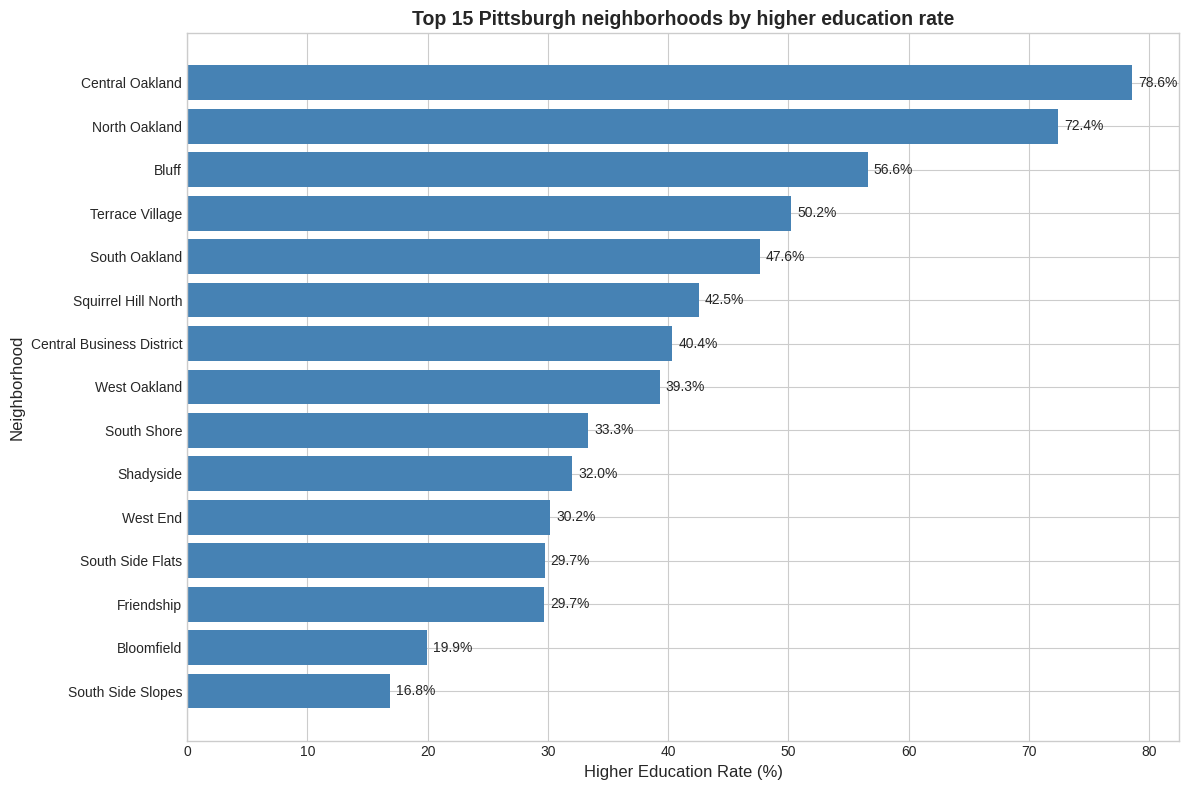

In [11]:
# get the top 15 neighborhoods for chart
top_15 = ranked.head(15)

# create a new chart in a size frame
plt.figure(figsize=(12, 8))

# make a horizontal chart and pick what goes on the x and y axis
bars = plt.barh(top_15['Neighborhood'], top_15['Higher_Ed_Rate'], color='steelblue')

# label the x axis and make the font size 12
plt.xlabel('Higher Education Rate (%)', fontsize=12)

# label the y axis and same thing
plt.ylabel('Neighborhood', fontsize=12)

# adding a title to the top in bold
plt.title('Top 15 Pittsburgh neighborhoods by higher education rate', fontsize=14, fontweight='bold')

# Flipping the y axis so it is not inverted
plt.gca().invert_yaxis()

# adding the percentage after each bar and pairing it up
for bar, val in zip(bars, top_15['Higher_Ed_Rate']):
    
    # adding text and doing alignment
    plt.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', 
             va='center', fontsize=10)

# fixing the spacing
plt.tight_layout()

# displaying the chart
plt.show()

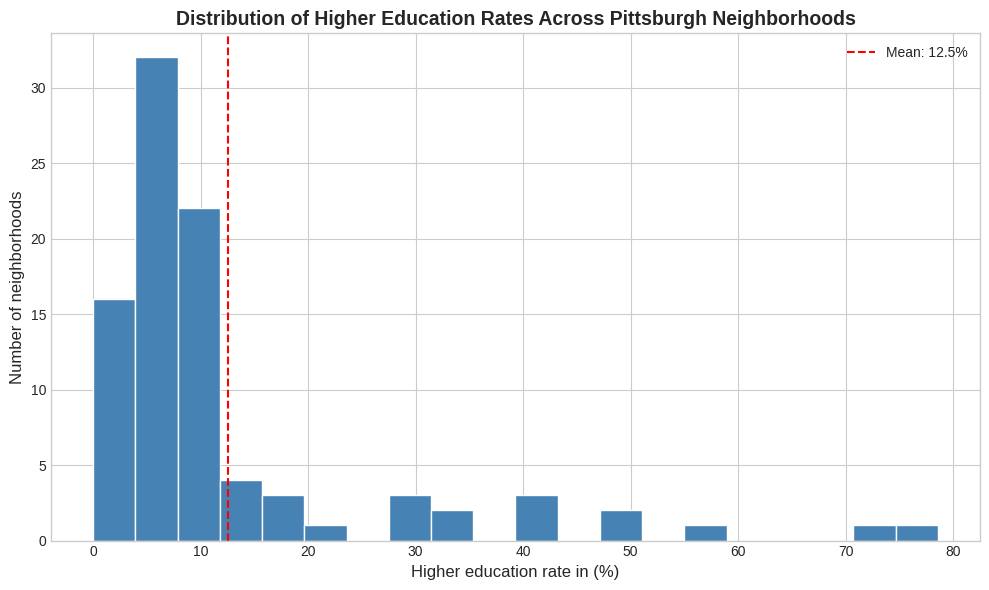

In [12]:
# Creating a histogram as well to see what falls where

# new figure
plt.figure(figsize=(10, 6))

# remove missing values and create a histogram
plt.hist(combined['Higher_Ed_Rate'].dropna(), bins=20, color='steelblue', edgecolor='white')

# label the axes
plt.xlabel('Higher education rate in (%)', fontsize=12)
plt.ylabel('Number of neighborhoods', fontsize=12)

# adding a title
plt.title('Distribution of Higher Education Rates Across Pittsburgh Neighborhoods', fontsize=14, fontweight='bold')

# show the mean in red and make a key
plt.axvline(combined['Higher_Ed_Rate'].mean(), color='red', linestyle='--', label=f"Mean: {combined['Higher_Ed_Rate'].mean():.1f}%")

# show the key or the legend in other words to demonstrate what red means
plt.legend()

# adjusting spacing
plt.tight_layout()

# displaying the chart
plt.show()

---
## Step seven: Export Results for Group Integration

Save the ranked data so teammates can combine it with their sub-metrics.

In [13]:
# making a clean copy
export_df = ranked[['Neighborhood', 'Higher_Ed_Rate', 'Rank']].copy()

# renaming the columns
export_df.columns = ['Neighborhood', 'Higher_Ed_Rate_Pct', 'Higher_Ed_Rank']

# saving the data to a csv file
export_df.to_csv('higher_education_metric.csv', index=False)

# make a confirmation message
print("Saved to 'higher_education_metric.csv'")
print("\nMerge if neccessary.")

Saved to 'higher_education_metric.csv'

Merge if neccessary.


---
## Conclusion

Based on my analysis of higher education rates across Pittsburgh neighborhoods:

The "Best" Neighborhood (by this metric): The best neighborhood was Central Oakland and then North Oakland just behind them.

Key Findings: First key finding is that proximity to universities is by far the biggest driver of the higher education rate. The top of the list is basically a map of Pitt, CMU, and Duquesne: Central Oakland (78.57%), North Oakland (72.41%), Bluff (56.59%), South Oakland (47.63%), and West Oakland (39.32%) all cluster around these campuses. Second key finding is there is a huge gap between the top neighborhoods and the rest of the city. The mean higher education rate is only 12.52% and the median is 7.46%, but Central Oakland is nearly 79%. This means a few neighborhoods by universities are pulling the average way up while most neighborhoods sit well below it. Third key finding is nighborhoods near universities but slightly further out, such as Squirrel Hill North at 42.55% and Shadyside at 32.04% still rank highly, probably because a lot of grad students and faculty live there even though they aren't walking distance to campus. Fourth key finding is the bottom of the list (Homewood West, Larimer, Bedford Dwellings, Mt. Oliver, Hays) is made up of lower-income neighborhoods that are further from the universities. This suggests my metric is measuring access and proximity to universities just as much as it is measuring a value for education. Also, a few results at the top and bottom are misleading because of tiny populations. South Shore ranks 9th with 33% but only has 12 total residents, and Chateau, North Shore, and St. Clair have 0% rates but also have very small populations. These neighborhoods should not be taken seriously in the ranking.

Personal Reflection:

Here is comparing my personal favorite to the "data-driven" best. My personal favorite neighborhood is: Shadyside. The data says the best neighborhood is: Central Oakland. These are different because I picked Shadyside based on things the data doesn't measure, like the walkability, the restaurants and shops on Walnut Street, and the general feel of the neighborhood. Central Oakland scores highest because it's packed with Pitt undergrads living in dorms and apartments, which makes the higher education rate extremely high but also means the neighborhood is dominated by student housing rather than the kind of place I would personally want to live long-term. Shadyside still ranked 10th on my metric, so it does reasonably well, but this comparison shows that so called "best" really depends on what you're measuring. A high higher education rate doesn't automatically mean a neighborhood is the most pleasant or well-rounded place to live. It just means a lot of people there are currently students, which is why combining this metric with my teammates such as Sadia's metrics will give a better picture.